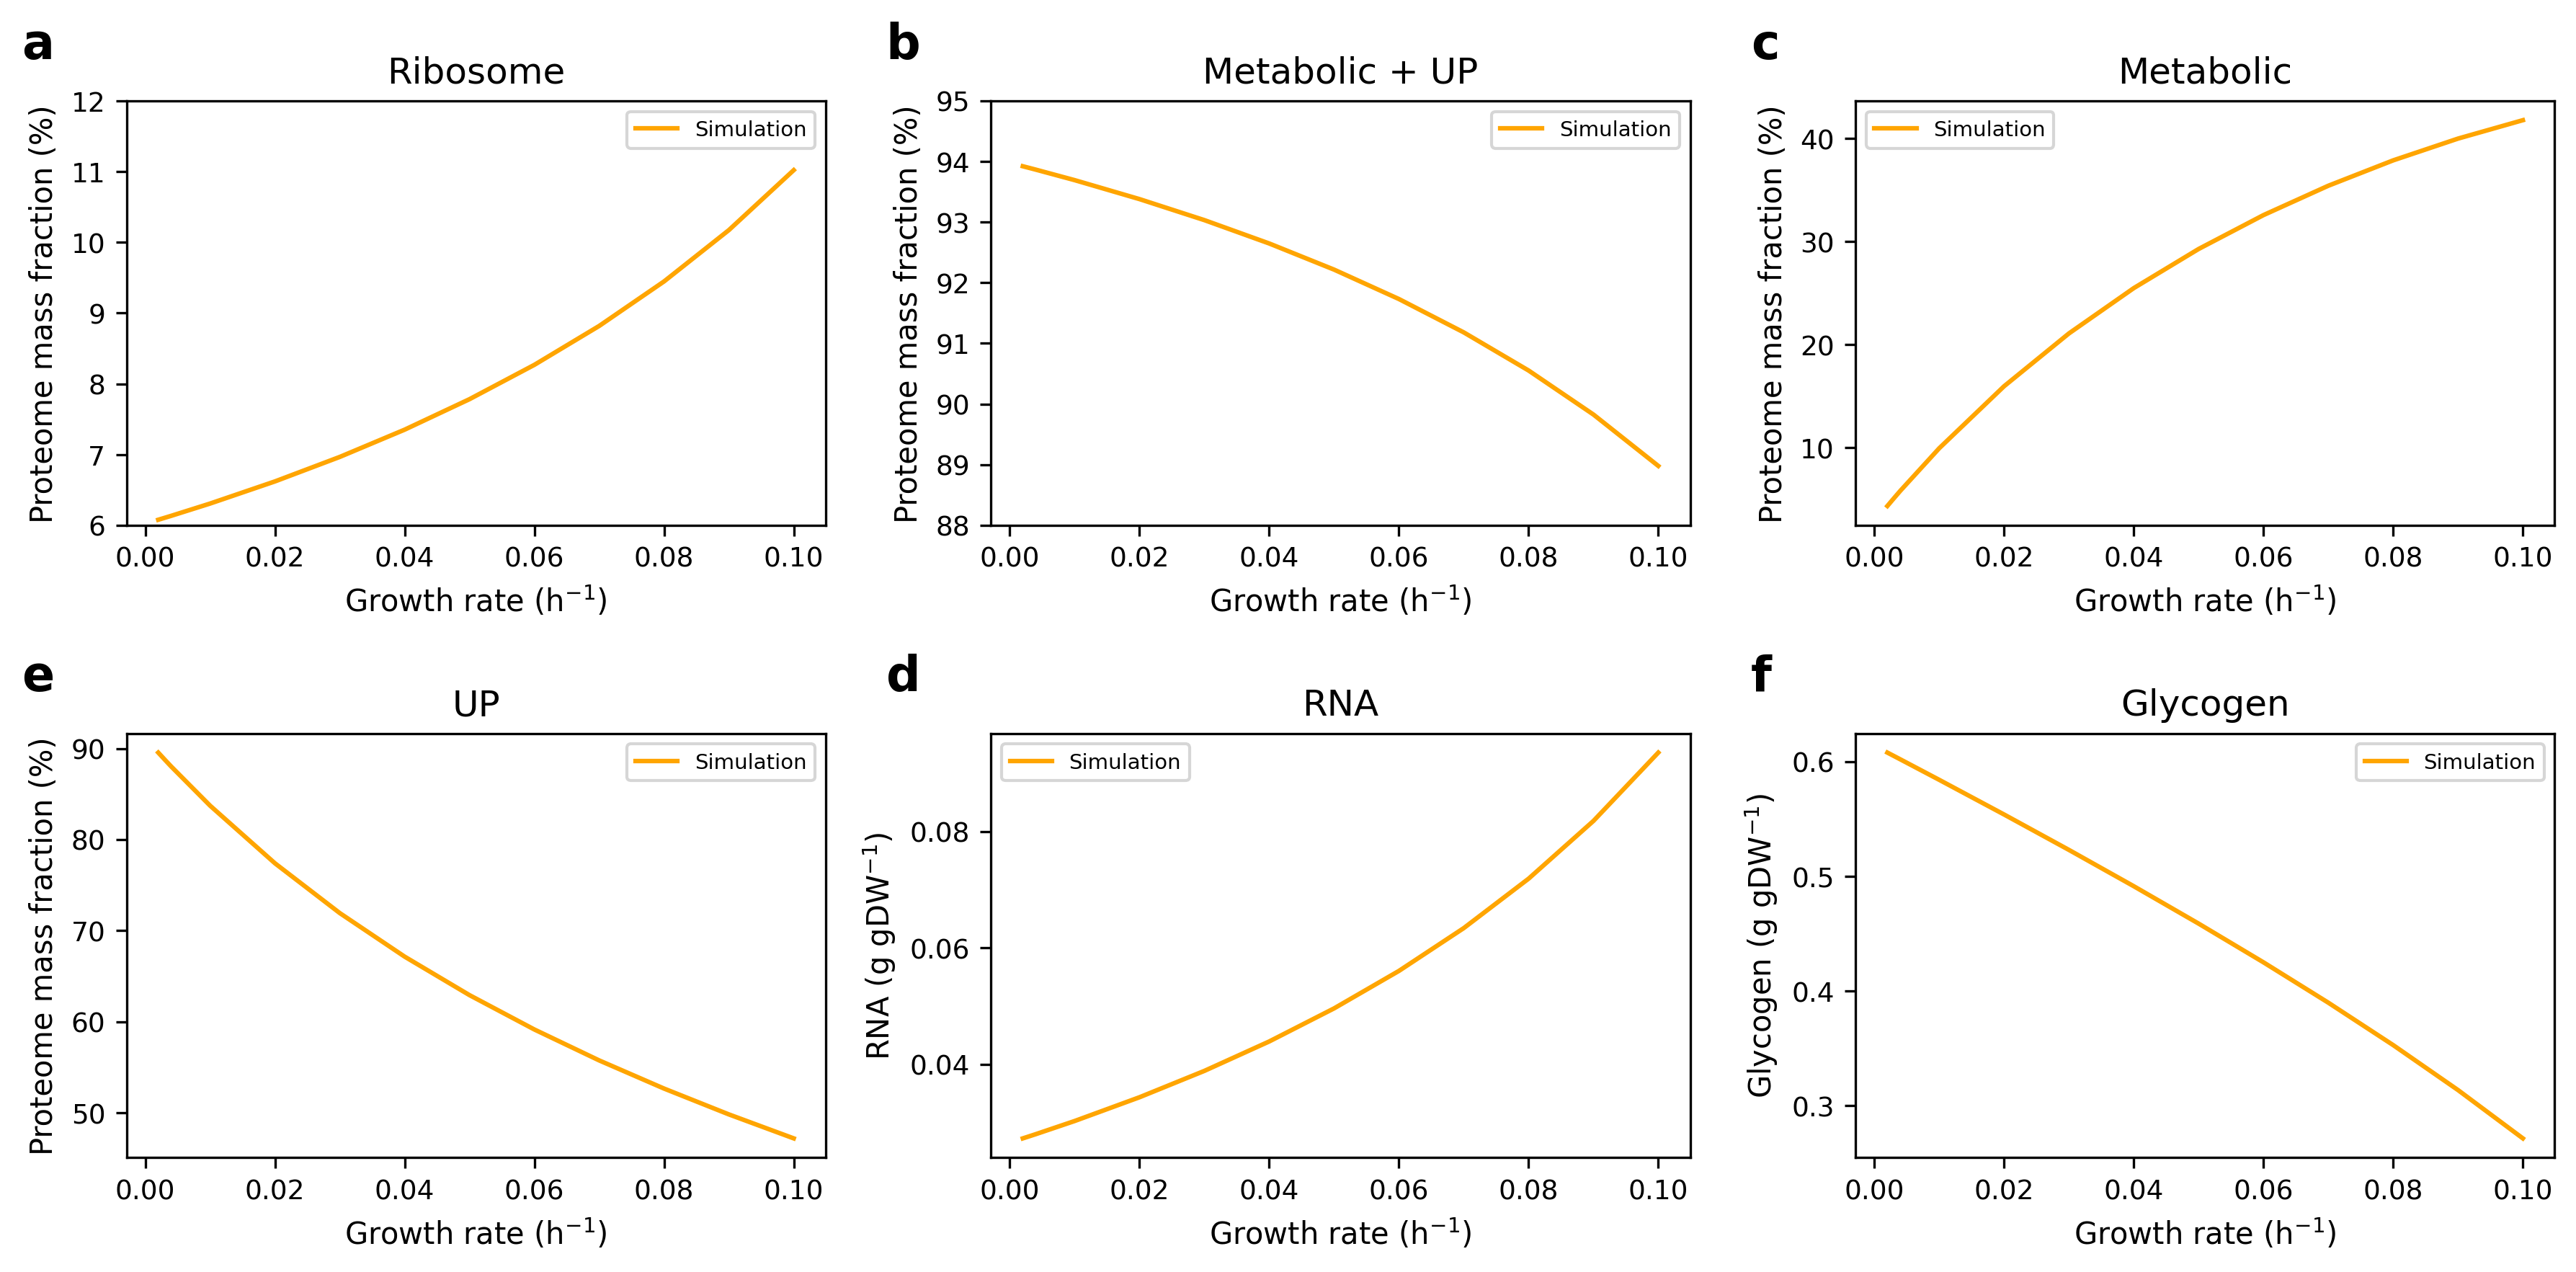

In [1]:
from simulation import Simulation
from extract_fluxes import Fluxes
import cobra
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def limitation_simulation():
    total_protein_mass=0.6
    up_phosphate_ratio=0.44*total_protein_mass
    methan_id,formate_id = "R944","R895"
    closed_reactions = ["R946", "R913", "R1165", "R983"]
    sim = Simulation()
    sim.set_parameter(model_file='pcMMP.xml', objective="R871", GAM=70, NGAM=1, excel_file='pcMMP.xlsx')
    sim.set_constraint = [f"UP >={up_phosphate_ratio}"]
    sim.close_reactions(closed_reactions)
    results = {
        "mu_list": [], "RNA_list": [],
         "metabolic_list": [],"up_list": [],
        "ribosome_list": [], "total_proteins": [],"glycogen_list": [],"metabolic_up_list":[]
    }
    mus=[0.002,0.003,0.004, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09,0.1]
    for i, mu in enumerate(mus, start=1):
        y = -183.67*mu + 40.367
        sim.kcat_ribo = y
       
        sim.file_path = f"output/lp_file_phosphate_proteome{i}.lp"
        sim.output_file = f"output/output_phosphate_proteome{i}.lp"
        if sim.check_mu_optimal(mu):
            fluxes = Fluxes(sim.model, f'output/output_phosphate_proteome{i}.lp')
            results["mu_list"].append(mu)
            results["RNA_list"].append(fluxes.extract_reaction_flux("RNA"))
            total_protein = fluxes.extract_reaction_flux("total_protein")
            up = fluxes.extract_reaction_flux("UP")
            results["metabolic_list"].append(((fluxes.extract_reaction_flux("metaboicMass")) / total_protein)*100)
            results["ribosome_list"].append((fluxes.extract_reaction_flux("ribosome_mass") / total_protein)*100)
            results["metabolic_up_list"].append(((up + fluxes.extract_reaction_flux("metaboicMass")) / total_protein)*100)
            results["total_proteins"].append(total_protein)
            results["up_list"].append((up/total_protein)*100)
            results["glycogen_list"].append(fluxes.extract_reaction_flux("Glycogen"))
          
        else:
            print(f"mu={mu} is not optimal")

    return results

def plot(results_phosphate):
    plt.rcParams.update({
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize":9,
        "ytick.labelsize": 9,
        "legend.fontsize": 7
    })

    mu_list = results_phosphate['mu_list']

    fig, axes = plt.subplots(2, 3, figsize=(12, 6), dpi=300)  
    subplot_labels = ["a", "b", "c", "d","e","f"]

    # --- Ribosome ---
    axes[0, 0].plot(mu_list, results_phosphate['ribosome_list'], label="Simulation", color='orange')
    axes[0, 0].set_title("Ribosome")
    axes[0, 0].set_ylabel("Proteome mass fraction (%)")
    axes[0, 0].set_xlabel("Growth rate (h$^{-1}$)")
    axes[0, 0].legend()
    axes[0, 0].set_ylim(6, 12)
    axes[0, 0].text(-0.15, 1.1, subplot_labels[0], transform=axes[0, 0].transAxes, fontsize=16, fontweight='bold')

    # --- Metabolic + UP ---
    axes[0, 1].plot(mu_list, results_phosphate['metabolic_up_list'], label="Simulation", color='orange')
    axes[0, 1].set_title("Metabolic + UP")
    axes[0, 1].set_ylabel("Proteome mass fraction (%)")
    axes[0, 1].set_xlabel("Growth rate (h$^{-1}$)")
    axes[0, 1].legend()
    axes[0, 1].set_ylim(88, 95)
    axes[0, 1].text(-0.15, 1.1, subplot_labels[1], transform=axes[0, 1].transAxes, fontsize=16, fontweight='bold')

    # --- Protein ---
    axes[0, 2].plot(mu_list, results_phosphate['metabolic_list'], label="Simulation", color='orange')
    axes[0, 2].set_title("Metabolic")
    axes[0, 2].set_ylabel("Proteome mass fraction (%)")
    axes[0, 2].set_xlabel("Growth rate (h$^{-1}$)")
    axes[0, 2].legend()
    axes[0, 2].text(-0.15, 1.1, subplot_labels[2], transform=axes[0, 2].transAxes, fontsize=16, fontweight='bold')


    # --- UP  ---
  
    axes[1, 0].plot(mu_list, results_phosphate['up_list'], label="Simulation", color='orange')
    axes[1, 0].set_title("UP")
    axes[1, 0].set_ylabel("Proteome mass fraction (%)")
    axes[1, 0].set_xlabel("Growth rate (h$^{-1}$)")
    axes[1, 0].legend()
    axes[1, 0].text(-0.15, 1.1, subplot_labels[4], transform=axes[1, 0].transAxes, fontsize=16, fontweight='bold')


    # --- RNA ---
    axes[1, 1].plot(mu_list, results_phosphate['RNA_list'], label="Simulation", color='orange')
    axes[1, 1].set_title("RNA")
    axes[1, 1].set_ylabel("RNA (g gDW$^{-1}$)")
    axes[1, 1].set_xlabel("Growth rate (h$^{-1}$)")
    axes[1, 1].legend()
    axes[1, 1].text(-0.15, 1.1, subplot_labels[3], transform=axes[1, 1].transAxes, fontsize=16, fontweight='bold')

    
    # --- Glycogen ----
    axes[1, 2].plot(mu_list, results_phosphate['glycogen_list'], label="Simulation", color='orange')
    axes[1, 2].set_title("Glycogen")
    axes[1, 2].set_ylabel("Glycogen (g gDW$^{-1}$)")
    axes[1, 2].set_xlabel("Growth rate (h$^{-1}$)")
    axes[1, 2].legend()
    axes[1, 2].text(-0.15, 1.1, subplot_labels[5], transform=axes[1, 2].transAxes, fontsize=16, fontweight='bold')

    plt.tight_layout()
    plt.savefig("Figures/phosphate_limited_distributed_proteome.png", dpi=300)
    plt.show()

if __name__ == "__main__":
    results_phosphate = limitation_simulation()
  
    plot(results_phosphate)